Muqadas Yasin — Week 1 Task

Online Retail II — Exploratory Data Analysis (EDA)


Step 0 — Upload dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Online Retail II Dataset.csv to Online Retail II Dataset.csv


Step 0b — Imports

In [2]:
import os
import pandas as pd            # for loading and working with tables of data
import numpy as np             # for numeric operations
import matplotlib.pyplot as plt  # for drawing charts
import seaborn as sns          # for nicer-looking statistical charts

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Create a folder to save all charts into
CHART_DIR = "eda_charts"
os.makedirs(CHART_DIR, exist_ok=True)

def save_and_show(fig, filename):
    """Small helper: saves a chart as PNG, then shows it on screen."""
    fig.tight_layout()
    fig.savefig(os.path.join(CHART_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

Step 1 — Load dataset & basic info

In [3]:
# encoding="utf-8-sig" removes a hidden character (BOM) at the start of the file
df = pd.read_csv("Online Retail II Dataset.csv", encoding="utf-8-sig")

print("Shape of dataset (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types of each column:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())

Shape of dataset (rows, columns): (525461, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types of each column:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

First 5 rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1    489434    79323P                   PINK CHERRY LIGHTS        12   
2    489434    79323W                  WHITE CHERRY LIGHTS        12   
3    489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4    489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2009 7:45       6.95     13085.0  United Kingdom  
1  12/1/2009 7:45       6.75     13085.0

Step 2 — Missing values & duplicates

Columns with missing values:
             Missing Count  Missing %
CustomerID          107927      20.54
Description           2928       0.56


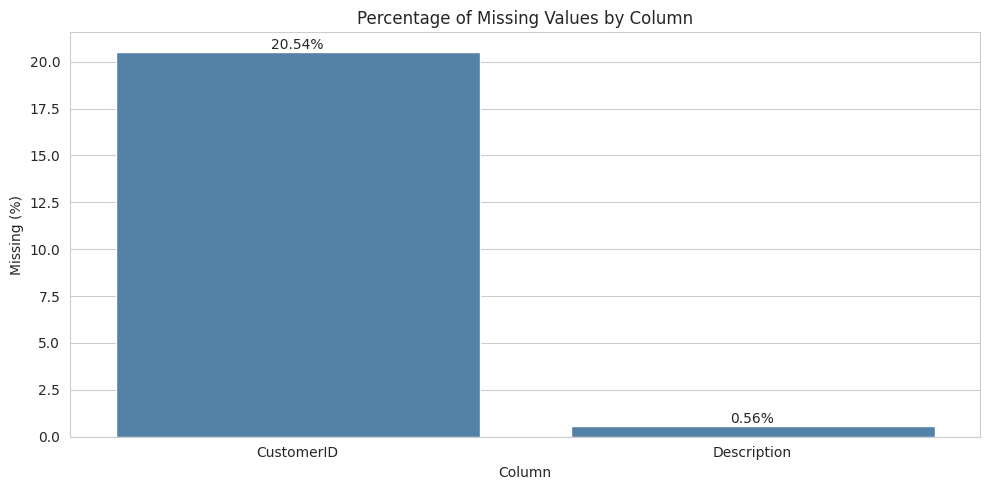


Number of fully duplicated rows: 6865
That is 1.31% of the dataset


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct.round(2)
})
missing_report = missing_report[missing_report["Missing Count"] > 0].sort_values(
    "Missing Count", ascending=False
)
print("Columns with missing values:")
print(missing_report)

# Chart: missing values by column
fig, ax = plt.subplots()
sns.barplot(x=missing_report.index, y=missing_report["Missing %"], ax=ax, color="steelblue")
ax.set_title("Percentage of Missing Values by Column")
ax.set_xlabel("Column")
ax.set_ylabel("Missing (%)")
for i, v in enumerate(missing_report["Missing %"]):
    ax.text(i, v, f"{v}%", ha="center", va="bottom")
save_and_show(fig, "01_missing_values.png")

# Duplicate rows
dup_count = df.duplicated().sum()
print(f"\nNumber of fully duplicated rows: {dup_count}")
print(f"That is {dup_count/len(df)*100:.2f}% of the dataset")

Step 3 — Extra data quality checks

In [5]:
# Invoice numbers starting with 'C' mean the order was CANCELLED/returned
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["IsCancelled"] = df["InvoiceNo"].str.startswith("C")

cancelled_count = df["IsCancelled"].sum()
neg_qty = (df["Quantity"] < 0).sum()
neg_price = (df["UnitPrice"] < 0).sum()
zero_price = (df["UnitPrice"] == 0).sum()
missing_cust = df["CustomerID"].isnull().sum()

print(f"Cancelled invoices (start with 'C'): {cancelled_count} ({cancelled_count/len(df)*100:.2f}%)")
print(f"Rows with negative Quantity: {neg_qty}")
print(f"Rows with negative UnitPrice: {neg_price}")
print(f"Rows with UnitPrice equal to 0: {zero_price}")
print(f"Rows with missing CustomerID: {missing_cust} ({missing_cust/len(df)*100:.2f}%)")

Cancelled invoices (start with 'C'): 10206 (1.94%)
Rows with negative Quantity: 12326
Rows with negative UnitPrice: 3
Rows with UnitPrice equal to 0: 3687
Rows with missing CustomerID: 107927 (20.54%)


Step 4 — Derived columns

In [6]:
# (DO NOT delete or filter any original rows)

# Convert date column from text to real date format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Revenue = Quantity x Price for each line item
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Extract month (e.g. "2010-05") to group sales by month
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

print("New columns added: Revenue, InvoiceMonth, IsCancelled")
print(df[["InvoiceNo", "Quantity", "UnitPrice", "Revenue", "InvoiceMonth"]].head())

New columns added: Revenue, InvoiceMonth, IsCancelled
  InvoiceNo  Quantity  UnitPrice  Revenue InvoiceMonth
0    489434        12       6.95     83.4      2009-12
1    489434        12       6.75     81.0      2009-12
2    489434        12       6.75     81.0      2009-12
3    489434        48       2.10    100.8      2009-12
4    489434        24       1.25     30.0      2009-12


Step 5 — Top 10 best-selling products

Top 10 products by QUANTITY sold:
Description
WHITE HANGING HEART T-LIGHT HOLDER    57733
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54698
BROCADE RING PURSE                    47647
PACK OF 72 RETRO SPOT CAKE CASES      46106
ASSORTED COLOUR BIRD ORNAMENT         44925
60 TEATIME FAIRY CAKE CASES           36326
PACK OF 60 PINK PAISLEY CAKE CASES    31822
JUMBO BAG RED RETROSPOT               30727
SMALL POPCORN HOLDER                  29500
STRAWBERRY CERAMIC TRINKET BOX        26563
Name: Quantity, dtype: int64


/tmp/ipykernel_1479/4289999465.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_qty.values, y=top_qty.index, ax=ax, palette="Blues_r")


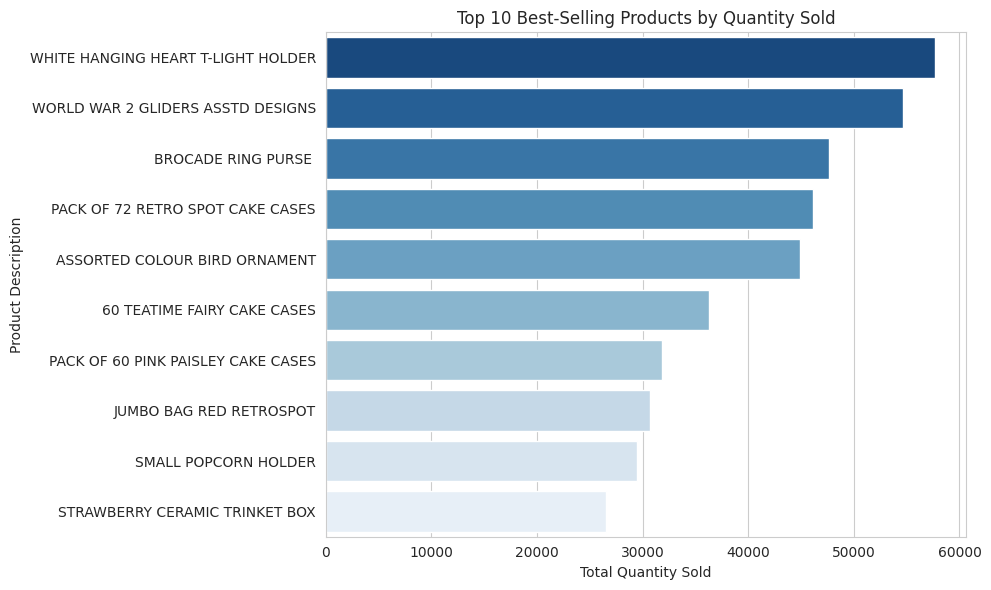


Top 10 products by REVENUE:
Description
REGENCY CAKESTAND 3 TIER               163051.46
WHITE HANGING HEART T-LIGHT HOLDER     157865.43
DOTCOM POSTAGE                         116401.99
ASSORTED COLOUR BIRD ORNAMENT           72454.12
PAPER CHAIN KIT 50'S CHRISTMAS          57870.20
JUMBO BAG RED RETROSPOT                 56444.61
PARTY BUNTING                           49645.52
ROTATING SILVER ANGELS T-LIGHT HLDR     47672.49
POSTAGE                                 46092.36
JUMBO BAG STRAWBERRY                    36699.61
Name: Revenue, dtype: float64


/tmp/ipykernel_1479/4289999465.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_revenue.values, y=top_revenue.index, ax=ax, palette="Greens_r")


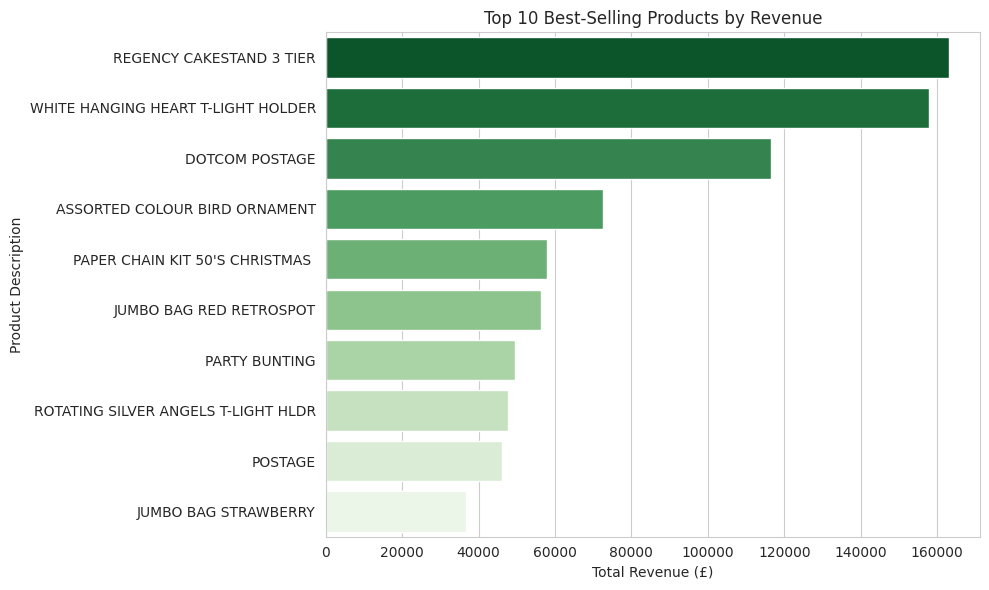

In [7]:
# By quantity sold
top_qty = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
print("Top 10 products by QUANTITY sold:")
print(top_qty)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_qty.values, y=top_qty.index, ax=ax, palette="Blues_r")
ax.set_title("Top 10 Best-Selling Products by Quantity Sold")
ax.set_xlabel("Total Quantity Sold")
ax.set_ylabel("Product Description")
save_and_show(fig, "02_top10_products_quantity.png")

# By revenue generated
top_revenue = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
print("\nTop 10 products by REVENUE:")
print(top_revenue)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_revenue.values, y=top_revenue.index, ax=ax, palette="Greens_r")
ax.set_title("Top 10 Best-Selling Products by Revenue")
ax.set_xlabel("Total Revenue (£)")
ax.set_ylabel("Product Description")
save_and_show(fig, "03_top10_products_revenue.png")

Step 6 — Sales performance by country

Top 15 countries by revenue:
                 TotalRevenue  TotalOrders  TotalQuantity  UniqueCustomers
Country                                                                   
United Kingdom    8194777.533        26633        4429046             4035
EIRE               352242.730          457         188704                5
Netherlands        263863.410          150         181823               23
Germany            196290.351          513         107133               68
France             130769.900          297          74471               47
Sweden              51213.510           83          52238               16
Denmark             46972.950           33         227030                9
Switzerland         43343.410           50          22053               14
Spain               37084.900           85          18332               25
Australia           30051.800           50          20053               15
Portugal            23769.780           57          11878              

/tmp/ipykernel_1479/3367204033.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries["TotalRevenue"].values, y=top_countries.index, ax=ax, palette="mako")


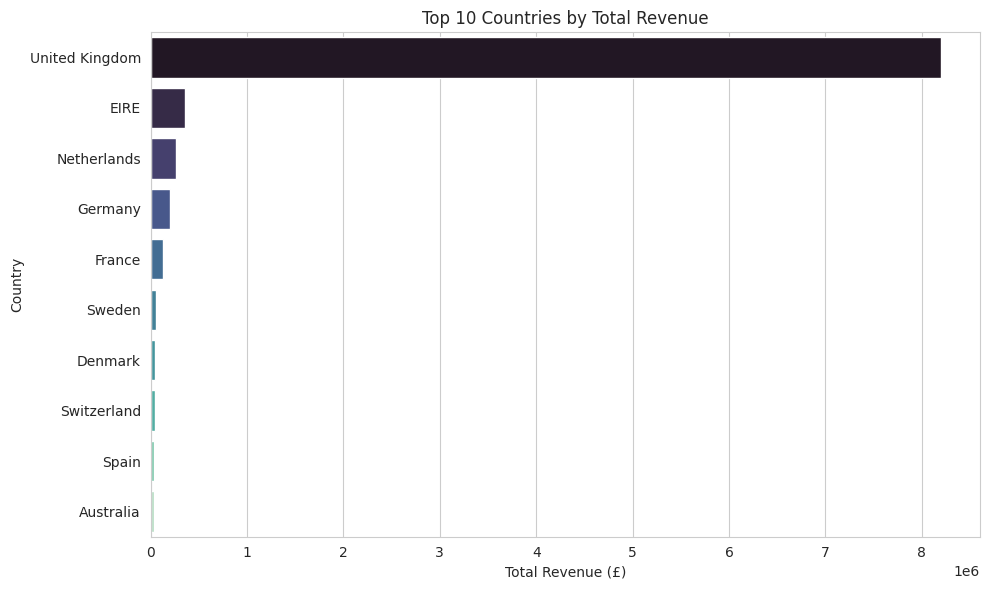

/tmp/ipykernel_1479/3367204033.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=non_uk["TotalRevenue"].values, y=non_uk.index, ax=ax, palette="rocket")


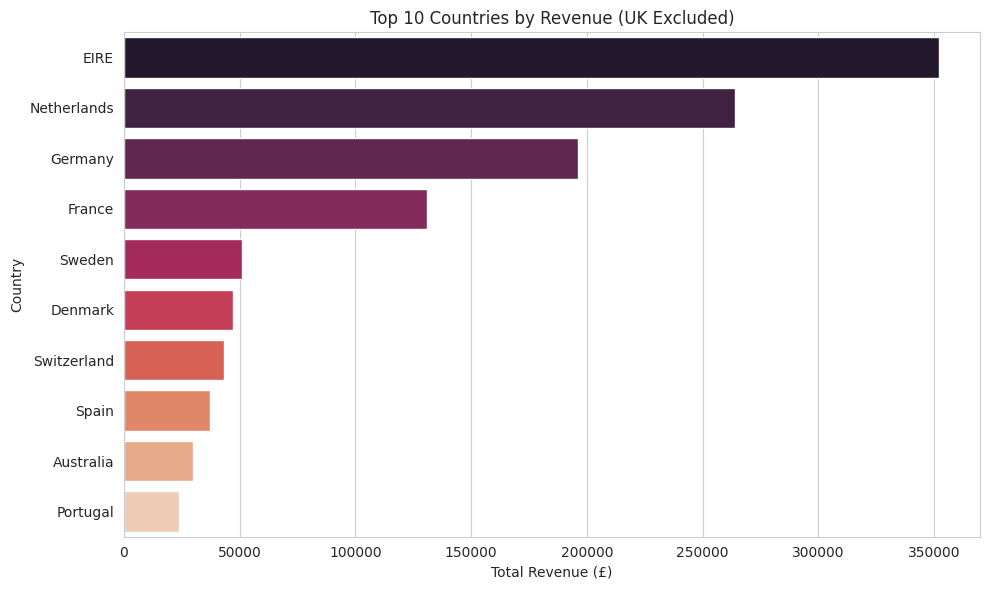


UK's share of total revenue: 85.9%


In [8]:
country_summary = (
    df.groupby("Country")
    .agg(
        TotalRevenue=("Revenue", "sum"),
        TotalOrders=("InvoiceNo", "nunique"),
        TotalQuantity=("Quantity", "sum"),
        UniqueCustomers=("CustomerID", "nunique"),
    )
    .sort_values("TotalRevenue", ascending=False)
)
print("Top 15 countries by revenue:")
print(country_summary.head(15))

# Chart: Top 10 countries including UK
top_countries = country_summary.head(10)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_countries["TotalRevenue"].values, y=top_countries.index, ax=ax, palette="mako")
ax.set_title("Top 10 Countries by Total Revenue")
ax.set_xlabel("Total Revenue (£)")
ax.set_ylabel("Country")
save_and_show(fig, "04_top10_countries.png")

# Chart: Top 10 countries excluding UK (so the rest are visible on scale)
non_uk = country_summary.drop("United Kingdom").head(10)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=non_uk["TotalRevenue"].values, y=non_uk.index, ax=ax, palette="rocket")
ax.set_title("Top 10 Countries by Revenue (UK Excluded)")
ax.set_xlabel("Total Revenue (£)")
ax.set_ylabel("Country")
save_and_show(fig, "05_top10_countries_excl_uk.png")

uk_share = country_summary.loc["United Kingdom", "TotalRevenue"] / country_summary["TotalRevenue"].sum() * 100
print(f"\nUK's share of total revenue: {uk_share:.1f}%")

Step 7 — Revenue over time

InvoiceMonth
2009-12     799847.110
2010-01     624032.892
2010-02     533091.426
2010-03     765848.761
2010-04     590580.432
2010-05     615322.830
2010-06     679786.610
2010-07     575236.360
2010-08     656776.340
2010-09     853650.431
2010-10    1045168.350
2010-11    1422654.642
2010-12     377488.450
Name: Revenue, dtype: float64


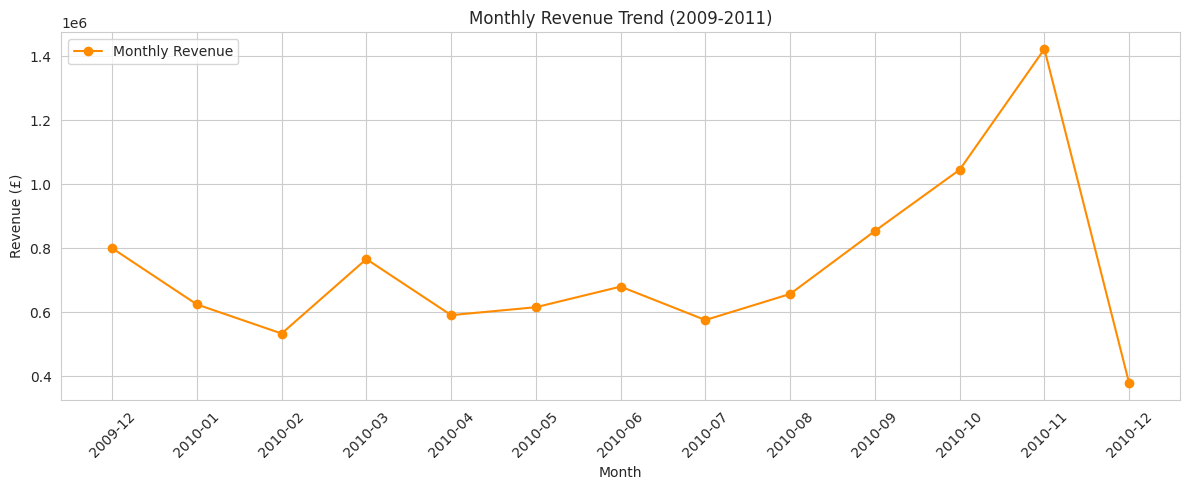

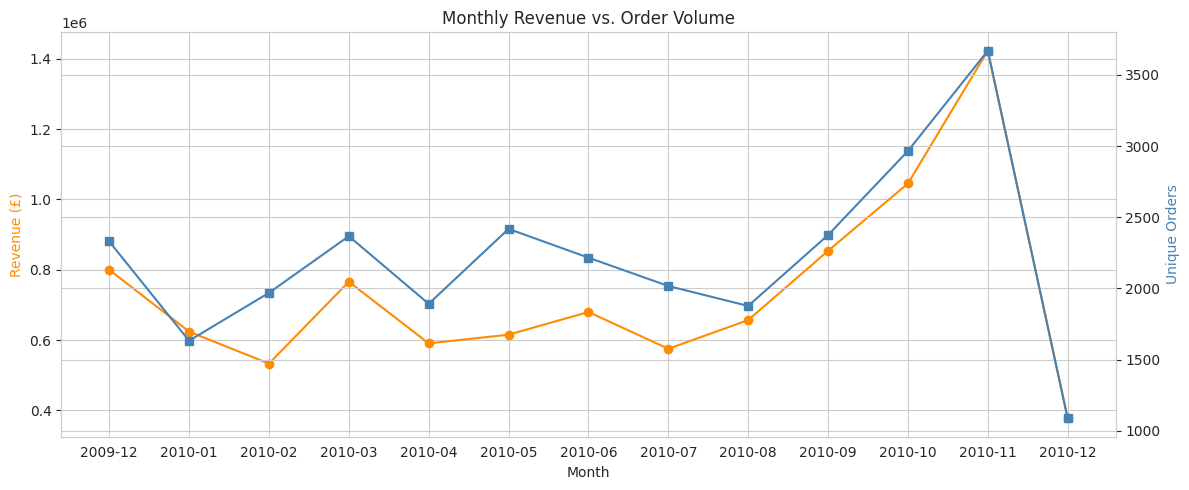

In [9]:
monthly_revenue = df.groupby("InvoiceMonth")["Revenue"].sum().sort_index()
print(monthly_revenue)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_revenue.index, monthly_revenue.values, marker="o", color="darkorange", label="Monthly Revenue")
ax.set_title("Monthly Revenue Trend (2009-2011)")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (£)")
ax.legend()
plt.xticks(rotation=45)
save_and_show(fig, "06_monthly_revenue_trend.png")

# Extra: compare revenue with number of orders per month
monthly_orders = df.groupby("InvoiceMonth")["InvoiceNo"].nunique()
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly_revenue.index, monthly_revenue.values, marker="o", color="darkorange", label="Revenue (£)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue (£)", color="darkorange")
ax2 = ax1.twinx()
ax2.plot(monthly_orders.index, monthly_orders.values, marker="s", color="steelblue", label="Unique Orders")
ax2.set_ylabel("Unique Orders", color="steelblue")
ax1.set_title("Monthly Revenue vs. Order Volume")
plt.xticks(rotation=45)
save_and_show(fig, "07_revenue_vs_orders.png")

Step 8 — Correlation heatmap

            Quantity  UnitPrice   Revenue  CustomerID
Quantity    1.000000  -0.001931  0.156283   -0.011577
UnitPrice  -0.001931   1.000000  0.452592   -0.003266
Revenue     0.156283   0.452592  1.000000   -0.009475
CustomerID -0.011577  -0.003266 -0.009475    1.000000


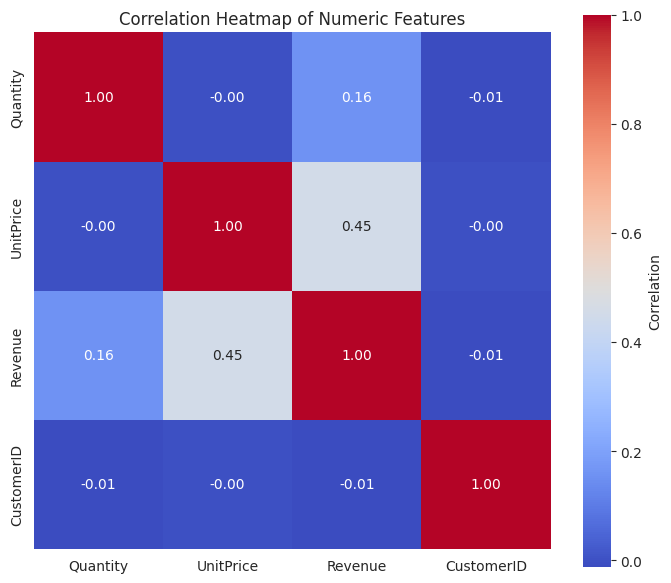

In [10]:
numeric_cols = ["Quantity", "UnitPrice", "Revenue", "CustomerID"]
corr = df[numeric_cols].corr()
print(corr)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            cbar_kws={"label": "Correlation"}, ax=ax)
ax.set_title("Correlation Heatmap of Numeric Features")
save_and_show(fig, "08_correlation_heatmap.png")

Step 9 — Outlier detection (box plots)

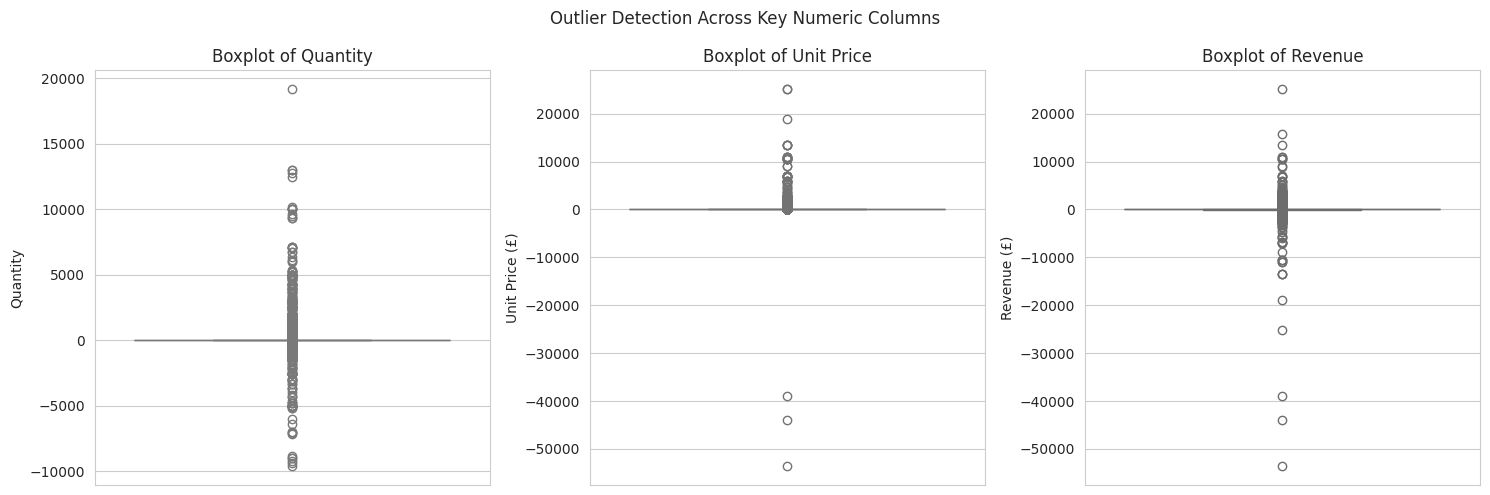

Outlier counts (IQR method):
  Quantity: 57870 outliers (11.01% of rows)
  UnitPrice: 35273 outliers (6.71% of rows)
  Revenue: 45872 outliers (8.73% of rows)


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df["Quantity"], ax=axes[0], color="lightblue")
axes[0].set_title("Boxplot of Quantity")
axes[0].set_ylabel("Quantity")

sns.boxplot(y=df["UnitPrice"], ax=axes[1], color="lightgreen")
axes[1].set_title("Boxplot of Unit Price")
axes[1].set_ylabel("Unit Price (£)")

sns.boxplot(y=df["Revenue"], ax=axes[2], color="salmon")
axes[2].set_title("Boxplot of Revenue")
axes[2].set_ylabel("Revenue (£)")

fig.suptitle("Outlier Detection Across Key Numeric Columns")
save_and_show(fig, "09_boxplots_outliers.png")

# IQR-based outlier counts
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lower) | (series > upper)).sum()

print("Outlier counts (IQR method):")
for col in ["Quantity", "UnitPrice", "Revenue"]:
    cnt = iqr_outlier_count(df[col])
    print(f"  {col}: {cnt} outliers ({cnt/len(df)*100:.2f}% of rows)")

Step 10 — Customer behaviour snapshot


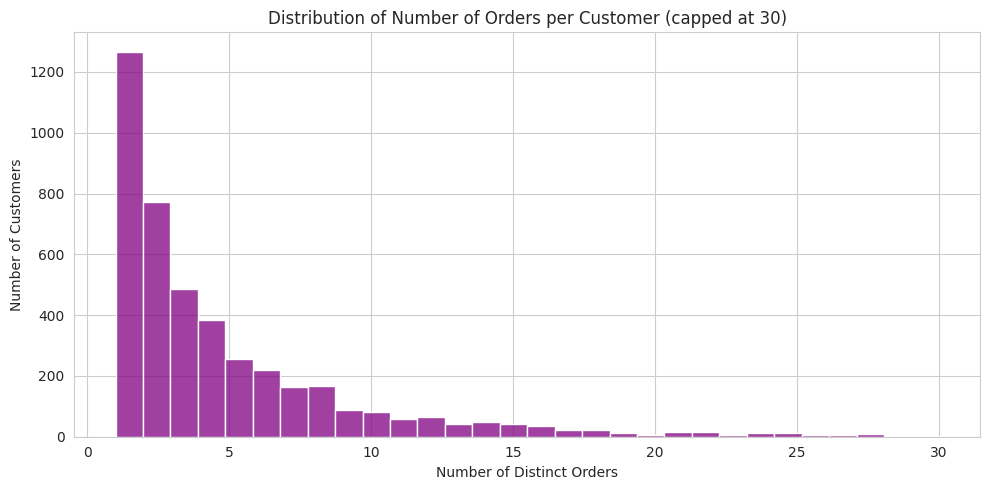

Total identified customers: 4383
Repeat customers (2+ orders): 3116 (71.1%)


In [12]:
cust_orders = df.dropna(subset=["CustomerID"]).groupby("CustomerID")["InvoiceNo"].nunique()

fig, ax = plt.subplots()
sns.histplot(cust_orders[cust_orders <= 30], bins=30, ax=ax, color="purple")
ax.set_title("Distribution of Number of Orders per Customer (capped at 30)")
ax.set_xlabel("Number of Distinct Orders")
ax.set_ylabel("Number of Customers")
save_and_show(fig, "10_orders_per_customer.png")

total_customers = cust_orders.shape[0]
repeat_customers = (cust_orders > 1).sum()
print(f"Total identified customers: {total_customers}")
print(f"Repeat customers (2+ orders): {repeat_customers} ({repeat_customers/total_customers*100:.1f}%)")

Bonus A — Extended statistical summary

In [13]:
stats_cols = ["Quantity", "UnitPrice", "Revenue"]
summary = df[stats_cols].describe().T
summary["skew"] = df[stats_cols].skew()
summary["kurtosis"] = df[stats_cols].kurtosis()
summary = summary.round(2)
print("Extended statistical summary:")
print(summary)

Extended statistical summary:
              count   mean     std       min   25%   50%    75%       max  \
Quantity   525461.0  10.34  107.42  -9600.00  1.00  3.00  10.00  19152.00   
UnitPrice  525461.0   4.69  146.13 -53594.36  1.25  2.10   4.21  25111.09   
Revenue    525461.0  18.15  160.33 -53594.36  3.75  9.95  17.70  25111.09   

             skew  kurtosis  
Quantity    36.04   6277.67  
UnitPrice -140.77  64868.34  
Revenue   -140.20  45029.95  


Bonus B — Pareto (80/20) analysis

Top 20% of products generate 79.8% of total revenue
Top 20% of customers generate 74.4% of total revenue (identified customers only)


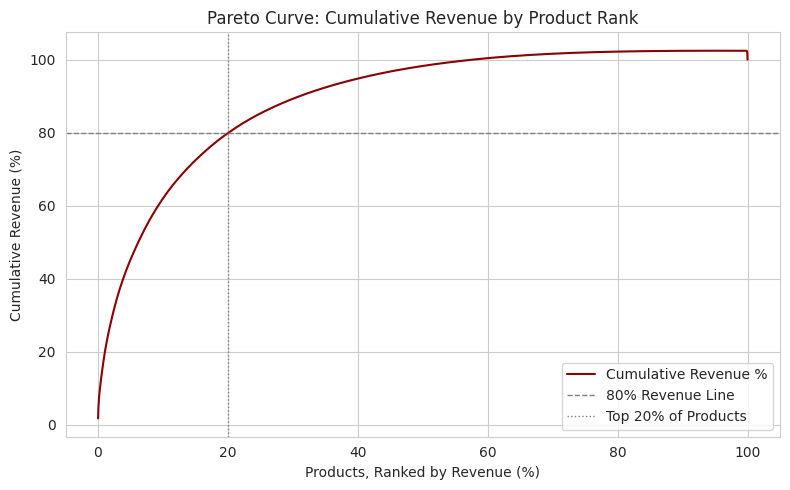

In [14]:
def pareto_share(series, top_fraction=0.2):
    sorted_vals = series.sort_values(ascending=False)
    n_top = max(1, int(len(sorted_vals) * top_fraction))
    return sorted_vals.iloc[:n_top].sum() / sorted_vals.sum() * 100

product_revenue = df.groupby("Description")["Revenue"].sum()
product_pareto_pct = pareto_share(product_revenue)
print(f"Top 20% of products generate {product_pareto_pct:.1f}% of total revenue")

customer_revenue = df.dropna(subset=["CustomerID"]).groupby("CustomerID")["Revenue"].sum()
customer_pareto_pct = pareto_share(customer_revenue)
print(f"Top 20% of customers generate {customer_pareto_pct:.1f}% of total revenue (identified customers only)")

sorted_rev = product_revenue.sort_values(ascending=False).reset_index(drop=True)
cum_pct = sorted_rev.cumsum() / sorted_rev.sum() * 100
product_rank_pct = (sorted_rev.index + 1) / len(sorted_rev) * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(product_rank_pct, cum_pct, color="darkred", label="Cumulative Revenue %")
ax.axhline(80, color="gray", linestyle="--", linewidth=1, label="80% Revenue Line")
ax.axvline(20, color="gray", linestyle=":", linewidth=1, label="Top 20% of Products")
ax.set_title("Pareto Curve: Cumulative Revenue by Product Rank")
ax.set_xlabel("Products, Ranked by Revenue (%)")
ax.set_ylabel("Cumulative Revenue (%)")
ax.legend()
save_and_show(fig, "11_pareto_products.png")

Bonus C — Day-of-week × hour-of-day demand heatmap

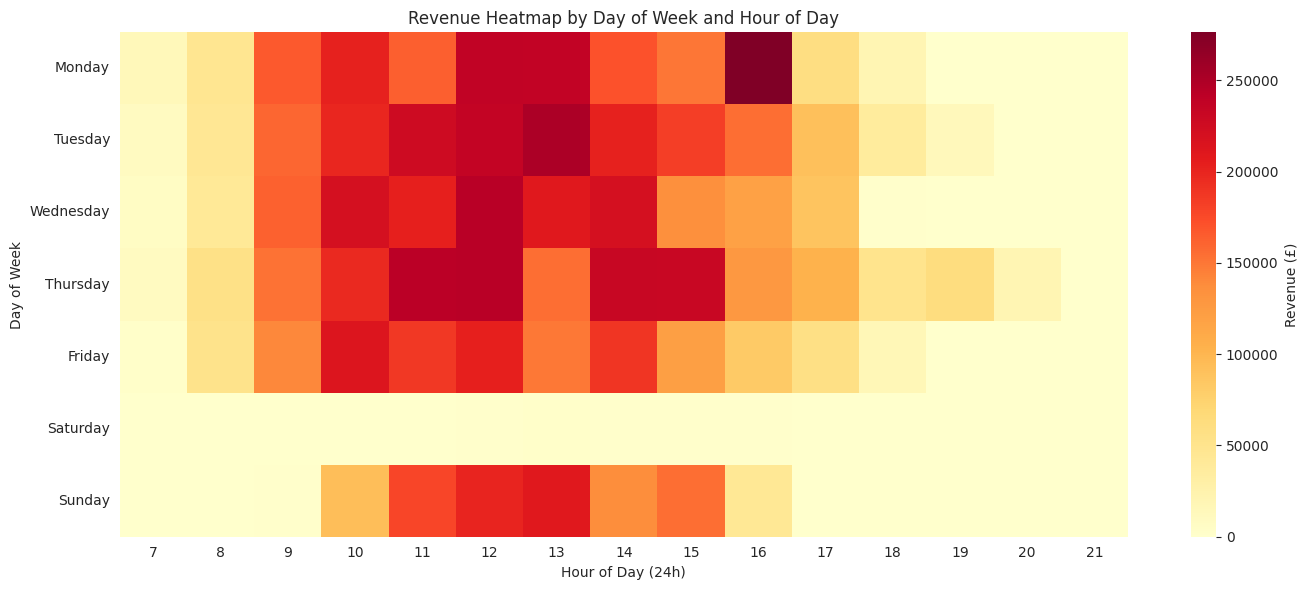

Highest-revenue day of the week: Thursday


In [15]:
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot = df.pivot_table(index="DayOfWeek", columns="Hour", values="Revenue",
                        aggfunc="sum", fill_value=0).reindex(day_order)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Revenue (£)"})
ax.set_title("Revenue Heatmap by Day of Week and Hour of Day")
ax.set_xlabel("Hour of Day (24h)")
ax.set_ylabel("Day of Week")
save_and_show(fig, "12_weekday_hour_heatmap.png")

busiest_day = df.groupby("DayOfWeek")["Revenue"].sum().reindex(day_order).idxmax()
print(f"Highest-revenue day of the week: {busiest_day}")

Bonus D — Gross vs. net revenue (cancellation impact)

Gross revenue (all rows, including cancellations): £9,539,484.63
Net revenue (cancellations excluded):               £10,169,340.00
Value tied up in cancelled orders:                  £-629,855.37
Cancellations represent 6.60% of gross revenue


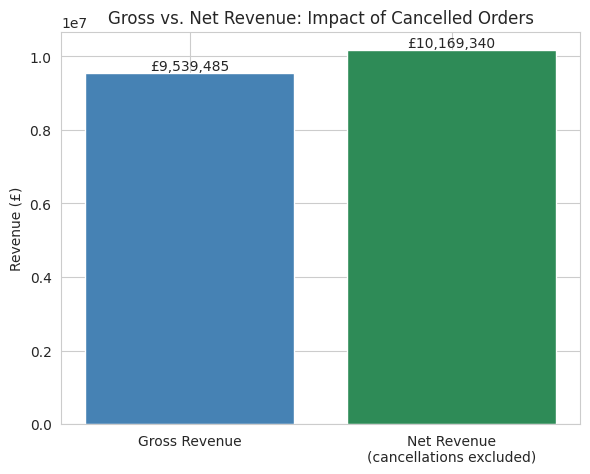

In [16]:
gross_revenue = df["Revenue"].sum()
net_revenue = df.loc[~df["IsCancelled"], "Revenue"].sum()
cancelled_value = df.loc[df["IsCancelled"], "Revenue"].sum()

print(f"Gross revenue (all rows, including cancellations): £{gross_revenue:,.2f}")
print(f"Net revenue (cancellations excluded):               £{net_revenue:,.2f}")
print(f"Value tied up in cancelled orders:                  £{cancelled_value:,.2f}")
print(f"Cancellations represent {abs(cancelled_value)/gross_revenue*100:.2f}% of gross revenue")

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(["Gross Revenue", "Net Revenue\n(cancellations excluded)"],
              [gross_revenue, net_revenue], color=["steelblue", "seagreen"])
ax.set_title("Gross vs. Net Revenue: Impact of Cancelled Orders")
ax.set_ylabel("Revenue (£)")
for b in bars:
    height = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, height, f"£{height:,.0f}", ha="center", va="bottom")
save_and_show(fig, "13_gross_vs_net_revenue.png")

Bonus E — RFM analysis & customer segmentation

RFM table (first 5 customers):
   CustomerID  Recency  Frequency  Monetary
0     12346.0       67         15    -64.68
1     12347.0        3          2   1323.32
2     12348.0       74          1    222.16
3     12349.0       43          4   2646.99
4     12351.0       11          1    300.93

Customer segment sizes:
Segment
Loyal              1384
Champions          1251
At Risk             929
Needs Attention     819
Name: count, dtype: int64


/tmp/ipykernel_1479/1681329346.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, ax=ax, palette="viridis")


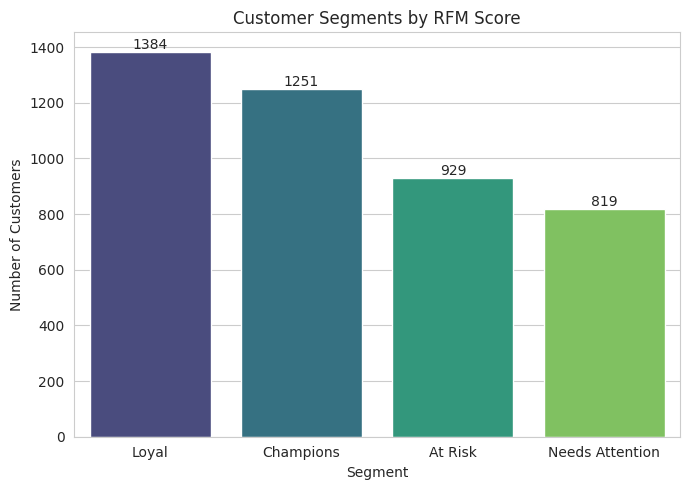

In [18]:
rfm_df = df.dropna(subset=["CustomerID"]).copy()
snapshot_date = rfm_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = rfm_df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum"),
).reset_index()

print("RFM table (first 5 customers):")
print(rfm.head())

rfm["R_Score"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

def label_segment(score):
    if score >= 10:
        return "Champions"
    elif score >= 7:
        return "Loyal"
    elif score >= 5:
        return "At Risk"
    else:
        return "Needs Attention"

rfm["Segment"] = rfm["RFM_Score"].apply(label_segment)
segment_counts = rfm["Segment"].value_counts()
print("\nCustomer segment sizes:")
print(segment_counts)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=segment_counts.index, y=segment_counts.values, ax=ax, palette="viridis")
ax.set_title("Customer Segments by RFM Score")
ax.set_xlabel("Segment")
ax.set_ylabel("Number of Customers")
for i, v in enumerate(segment_counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
save_and_show(fig, "14_rfm_segments.png")

**Business Insights**

1. The UK dominates revenue (85.9% of the total). EIRE, Netherlands, Germany, France are the next-biggest markets.
2. Missing CustomerID (107,927 rows, 20.54%) means a fifth of transactions have no purchase history to personalize.
3. Cancelled orders (10,206 rows, 1.94%) are still inside raw sales totals and should be excluded from official KPIs.
4. A small set of "hero" products drives a disproportionate share of quantity sold.
5. Revenue peaks sharply in November (£1,422,654.64), consistent with pre-holiday shopping.
6. 71.1% of identified customers are repeat buyers — a strong signal for recommendation systems.
7. Revenue correlates moderately with UnitPrice (0.45) and weakly with Quantity (0.16).
8. 6.7%–11% of rows are statistical outliers, plausibly wholesale/B2B orders rather than errors.